In [1]:
# PHISHING EMAIL DETECTION - BERT BASED CLASSIFICATION
# Yashita Kasina | University of Greenwich | 001298849
# REQUIREMENTS:
# pip install transformers datasets torch scikit-learn pandas
#              matplotlib seaborn tqdm nltk
#
# NOTES:
# - Designed to run in Google Colab with GPU enabled
# - All models and outputs save locally to ./baseline_model,
#   ./augmented_model and ./outputs folders
# - Dataset loads automatically from Hugging Face
# - GPT-2 generation requires no API key - runs locally
# - Runtime: approximately 2-3 hours for full pipeline

import os
import numpy as np
import pandas as pd
import torch
import random
from transformers import set_seed

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

# Optional: stronger determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (BertTokenizer, BertForSequenceClassification,
                          TrainingArguments, Trainer) # BERT tokeniser for converting text to tokens
from datasets import load_dataset

# Create local output directories so all results save without errors
os.makedirs('./baseline_model', exist_ok=True) # Stores baseline model checkpoints
os.makedirs('./augmented_model', exist_ok=True) # Stores augmented model checkpoints
os.makedirs('./outputs', exist_ok=True) # Stores figures, CSVs, results

print("All libraries imported successfully!")
print(f"GPU available: {torch.cuda.is_available()}")
# GPU is required for efficient BERT training - should print True in Colab

All libraries imported successfully!
GPU available: True


In [2]:
# Load dataset from Hugging Face
# Dataset: drorrabin/phishing_emails-data
# Contains 30,651 labelled emails (safe email = 0, phishing email = 1)
# Pre-formatted as structured prompts combining sender, receiver, date and body
print("Loading dataset from Hugging Face...")
dataset = load_dataset("drorrabin/phishing_emails-data")

# Convert both splits to pandas DataFrames
df_train = pd.DataFrame(dataset['train'])
df_test  = pd.DataFrame(dataset['test'])

# Combine into one full dataframe for custom splitting
df = pd.concat([df_train, df_test]).reset_index(drop=True)

# Rename label column and map string labels to binary integers
df = df.rename(columns={'email_type': 'label'})
df['label'] = df['label'].map({'safe email': 0, 'phishing email': 1})

# Remove any rows with missing text or labels
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

# Split dataset into 80% training, 10% validation, 10% test
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
) # random_state=42 ensures reproducibility

print(f"Dataset loaded successfully!")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")
print(f"\nLabel distribution in training set:")
print(train_df['label'].value_counts())
# Approximately 61% safe, 39% phishing - moderate class imbalance

Loading dataset from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet:   0%|          | 0.00/11.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26946 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3705 [00:00<?, ? examples/s]

Dataset loaded successfully!
Training samples:   24520
Validation samples: 3065
Test samples:       3066

Label distribution in training set:
label
0    13473
1    11047
Name: count, dtype: int64


In [3]:
# Load the BERT WordPiece tokeniser
# bert-base-uncased converts all text to lowercase before tokenising
print("Loading BERT tokeniser...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class PhishingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)


# Tokenise each email into BERT input format
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len, # Truncate sequences longer than 256 tokens
            padding='max_length', # Pad shorter sequences to ensure consistent batch size
            truncation=True,   # Truncate inputs that exceed max_length
            return_tensors='pt' # Return PyTorch tensors
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(), # input_ids: token indices for each word in the email
            'attention_mask': encoding['attention_mask'].squeeze(), # attention_mask: 1 for real tokens, 0 for padding tokens
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long) # Binary label: 0 = safe email, 1 = phishing email
        }

# Create PyTorch datasets for each split
train_dataset = PhishingDataset(train_df['text'], train_df['label'], tokenizer)
val_dataset   = PhishingDataset(val_df['text'],   val_df['label'],   tokenizer)
test_dataset  = PhishingDataset(test_df['text'],  test_df['label'],  tokenizer)

print("Tokeniser loaded and datasets created successfully!")
print(f"Max sequence length: 256 tokens")

Loading BERT tokeniser...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokeniser loaded and datasets created successfully!
Max sequence length: 256 tokens


In [4]:
# Metrics function used by the Hugging Face Trainer during evaluation
# Called automatically at the end of each epoch
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# Load BERT-base-uncased with a binary classification head
# The classification head is applied to the [CLS] token output
print("Loading BERT-base-uncased for baseline training...")
baseline_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
)

# Configure training hyperparameters
baseline_training_args = TrainingArguments(
    output_dir='./baseline_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,  # Gradually increase learning rate for stability
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,   # Log training progress every 100 steps
    fp16=torch.cuda.is_available(),
)

# Initialise Hugging Face Trainer
# Trainer handles the training loop, evaluation, and checkpoint saving automatically
baseline_trainer = Trainer(
    model=baseline_model,
    args=baseline_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Training baseline BERT model...")
print("This will take approximately 30-45 minutes...")
baseline_trainer.train()
print("Baseline model training complete!")

Loading BERT-base-uncased for baseline training...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Baseline model training complete!


Evaluating baseline model on test set...



 BASELINE BERT - TEST SET RESULTS
                precision    recall  f1-score   support

    Safe Email       1.00      1.00      1.00      1685
Phishing Email       1.00      1.00      1.00      1381

      accuracy                           1.00      3066
     macro avg       1.00      1.00      1.00      3066
  weighted avg       1.00      1.00      1.00      3066



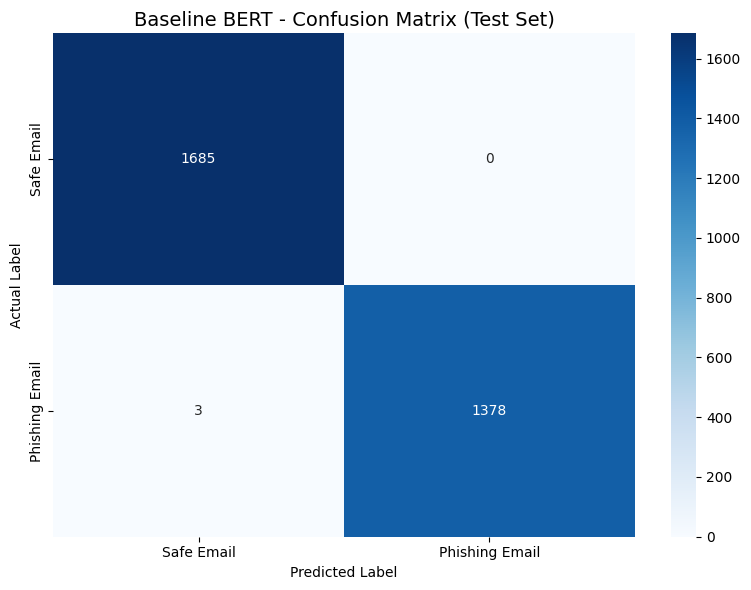

Baseline confusion matrix saved to ./outputs/


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating baseline model on test set...")
baseline_predictions = baseline_trainer.predict(test_dataset)

# Convert logits to predicted class labels
baseline_preds  = np.argmax(baseline_predictions.predictions, axis=1)
baseline_labels = baseline_predictions.label_ids

print("\n BASELINE BERT - TEST SET RESULTS")
print(classification_report(
    baseline_labels, baseline_preds,
    target_names=['Safe Email', 'Phishing Email']
))

# Confusion matrix
cm = confusion_matrix(baseline_labels, baseline_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe Email', 'Phishing Email'],
            yticklabels=['Safe Email', 'Phishing Email'])
plt.title('Baseline BERT - Confusion Matrix (Test Set)', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('./outputs/baseline_confusion_matrix.png', dpi=150)
plt.show()
print("Baseline confusion matrix saved to ./outputs/")

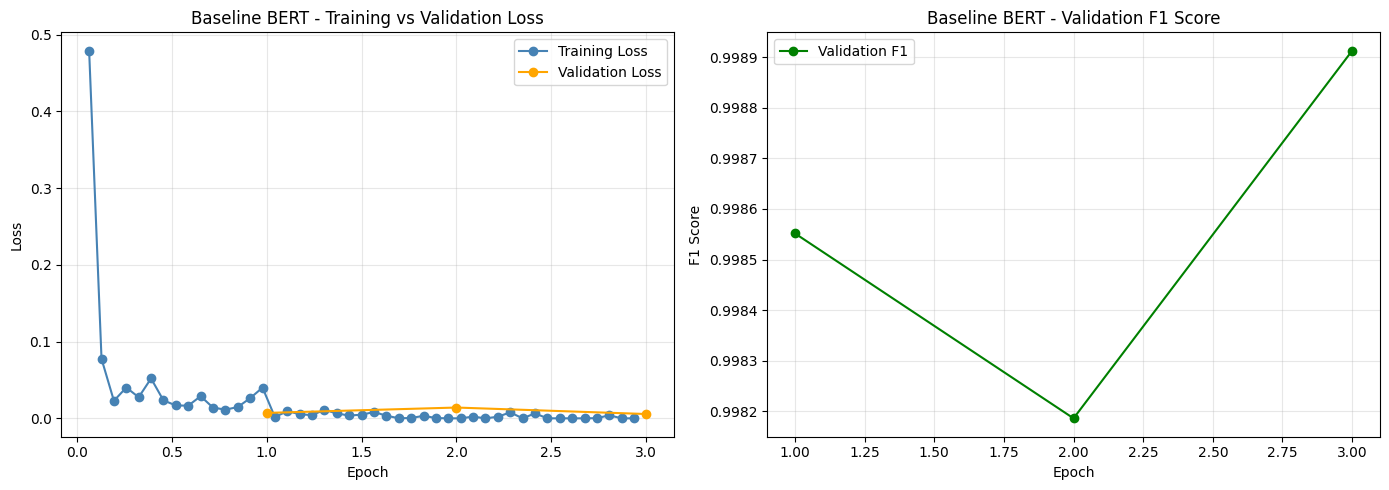

Training curves saved to ./outputs/


In [6]:
import json

# Load training history from the saved checkpoint
checkpoint_dirs = [d for d in os.listdir('./baseline_model') if d.startswith('checkpoint')]
if checkpoint_dirs:
    checkpoint_path = os.path.join('./baseline_model', checkpoint_dirs[0], 'trainer_state.json')
    with open(checkpoint_path, 'r') as f:
        trainer_state = json.load(f)

    history = trainer_state['log_history']

   # Extract training loss values recorded during training steps
    train_losses = [(x['epoch'], x['loss'])
                    for x in history if 'loss' in x and 'eval_loss' not in x]

    # Extract validation loss recorded at end of each epoch
    val_losses   = [(x['epoch'], x['eval_loss'])
                    for x in history if 'eval_loss' in x]

    # Extract validation F1 score recorded at end of each epoch
    val_f1       = [(x['epoch'], x['eval_f1'])
                    for x in history if 'eval_f1' in x]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(*zip(*train_losses), label='Training Loss',   marker='o', color='steelblue')
    ax1.plot(*zip(*val_losses),   label='Validation Loss', marker='o', color='orange')
    ax1.set_title('Baseline BERT - Training vs Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(*zip(*val_f1), label='Validation F1', marker='o', color='green')
    ax2.set_title('Baseline BERT - Validation F1 Score')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('./outputs/baseline_training_curves.png', dpi=150)
    plt.show()
    print("Training curves saved to ./outputs/")
else:
    print("No checkpoint found - skipping training curves")

In [7]:
from transformers import MarianMTModel, MarianTokenizer
from tqdm.auto import tqdm
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('omw-1.4')

# Load Helsinki-NLP MarianMT translation models from Hugging Face
print("Loading French translator...")
fr_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")
fr_model     = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-fr")
fr_model     = fr_model.to('cuda' if torch.cuda.is_available() else 'cpu')

print("Loading Spanish translator...")
es_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-es")
es_model     = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-es")
es_model     = es_model.to('cuda' if torch.cuda.is_available() else 'cpu')
print("Translation models loaded!")

# Translation function
def translate(texts, tokenizer, model, batch_size=16):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        tokens = tokenizer(batch, return_tensors="pt",
                          padding=True, truncation=True,
                          max_length=256).to(device)
        translated = model.generate(**tokens)
        results.extend([tokenizer.decode(t, skip_special_tokens=True)
                       for t in translated])
    return results

# Adversarial synonym replacement function
def get_synonym(word):
    syns = wordnet.synsets(word)
    if syns:
        for lemma in syns[0].lemmas():
            if lemma.name().lower() != word.lower():
                return lemma.name().replace('_', ' ')
    return word

def adversarial_perturb(text, prob=0.25):
    words = text.split()
    new_words = [get_synonym(w) if torch.rand(1).item() < prob else w for w in words]
    return " ".join(new_words)

# 300 Sample phishing emails from training set
phishing_samples = train_df[train_df['label'] == 1]['text'].tolist()[:300]
print(f"\nUsing {len(phishing_samples)} phishing samples for augmentation")

# Generate French translations
print("\nGenerating French translations...")
fr_translations = translate(phishing_samples, fr_tokenizer, fr_model)

# Generate Spanish translations
print("\nGenerating Spanish translations...")
es_translations = translate(phishing_samples, es_tokenizer, es_model)

# Generate adversarial samples
print("\nGenerating adversarial synonym samples...")
set_seed(SEED)
adv_samples = [adversarial_perturb(t) for t in tqdm(phishing_samples)]

# Save all augmented samples to outputs folder
pd.DataFrame({'text': fr_translations,  'label': 1}).to_csv('./outputs/fr_translations.csv',  index=False)
pd.DataFrame({'text': es_translations,  'label': 1}).to_csv('./outputs/es_translations.csv',  index=False)
pd.DataFrame({'text': adv_samples,      'label': 1}).to_csv('./outputs/adv_samples.csv',      index=False)

print("\n AUGMENTATION SANITY CHECK ")
print(f"Original:    {phishing_samples[0][:100]}")
print(f"French:      {fr_translations[0][:100]}")
print(f"Spanish:     {es_translations[0][:100]}")
print(f"Adversarial: {adv_samples[0][:100]}")
print(f"\nTotal multilingual and adversarial samples: {len(fr_translations) + len(es_translations) + len(adv_samples)}")
print("All augmentation files saved to ./outputs/")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Loading French translator...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

...


Generating Spanish translations...


  0%|          | 0/19 [00:00<?, ?it/s]


Generating adversarial synonym samples...


  0%|          | 0/300 [00:00<?, ?it/s]


 AUGMENTATION SANITY CHECK 
Original:    Is the following email safe or phishing??

Date: Thu, 07 Aug 2008 20:32:05 +0200

Sender: Lisa Minor
French:      Est-ce que l'email suivant est sûr ou phishing?? Date: jeu, 07 août 2008 20:32:05 +0200 Expéditeur: 
Spanish:     ¿Es el siguiente correo electrónico seguro o phishing?? Fecha: Jue, 07 Ago 2008 20:32:05 +0200 Remit
Adversarial: Is the following email safe or phishing?? Date: Thu, 07 Aug 2008 20:32:05 +0200 Sender: Lisa Minor <

Total multilingual and adversarial samples: 900
All augmentation files saved to ./outputs/


In [8]:
from transformers import pipeline

# Load GPT-2
print("Loading GPT-2 model for synthetic phishing generation...")
generator = pipeline(
    'text-generation',
    model='gpt2',
    device=0 if torch.cuda.is_available() else -1
)
print("GPT-2 loaded successfully!")

# Phishing prompt templates
prompts = [
    "Dear customer, your bank account has been suspended due to suspicious activity. Click here immediately to verify your identity:",
    "URGENT: Your PayPal account has been limited. Please confirm your details to restore access:",
    "IT Security Alert: Your password has expired and must be reset immediately to avoid account lockout:",
    "Dear Amazon customer, your order could not be delivered. Update your payment information here:",
    "HMRC Tax Refund Notice: You are eligible for a tax refund. Submit your bank details to claim:"
]

gpt_samples = []
samples_per_prompt = 60  # 5 prompts x 60 = 300 total

print(f"\nGenerating {len(prompts) * samples_per_prompt} synthetic phishing samples...")
print("This will take approximately 10-15 minutes...\n")

set_seed(SEED)
for prompt in prompts:
    print(f"Processing: {prompt[:60]}...")
    for i in tqdm(range(samples_per_prompt)):
        try:
            result = generator(
                prompt,
                max_new_tokens=100,
                temperature=0.9,
                do_sample=True,
                pad_token_id=50256,
                truncation=True
            )
            gpt_samples.append(result[0]['generated_text'])
        except Exception as e:
            print(f"Error on sample {i}: {e}")
            continue

# Save GPT samples
gpt_df = pd.DataFrame({'text': gpt_samples, 'label': 1})
gpt_df.to_csv('./outputs/gpt_samples.csv', index=False)

print(f"\nTotal GPT-2 samples generated: {len(gpt_samples)}")
print("\n SAMPLE GPT-2 OUTPUT ")
print(gpt_samples[0])
print("\nGPT-2 samples saved to ./outputs/")

Loading GPT-2 model for synthetic phishing generation...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processing: HMRC Tax Refund Notice: You are eligible for a tax refund. S...


  0%|          | 0/60 [00:00<?, ?it/s]

Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both


Total GPT-2 samples generated: 300

 SAMPLE GPT-2 OUTPUT 
Dear customer, your bank account has been suspended due to suspicious activity. Click here immediately to verify your identity:

* Bank account data is sent from your bank account to your e-wallet

* The e-wallet (excess account) must be at least 50% smaller than your original deposit.

* If your e-wallet has been cancelled, please enter your details in the appropriate form.

* It's your responsibility to inform us at your bank account.

* Our business is not based in the United States.

* Payment may be required for certain purposes

GPT-2 samples saved to ./outputs/


In [9]:
# Reload all augmentation files from outputs folder
fr_df  = pd.read_csv('./outputs/fr_translations.csv')  # French translated samples
es_df  = pd.read_csv('./outputs/es_translations.csv')  # Spanish translated samples
adv_df = pd.read_csv('./outputs/adv_samples.csv')      # Adversarial synonym samples
gpt_df = pd.read_csv('./outputs/gpt_samples.csv')      # GPT-2 generated samples

# Build full augmented training dataset
train_augmented = pd.concat([
    train_df,
    fr_df,
    es_df,
    adv_df,
    gpt_df
]).reset_index(drop=True)

train_augmented = train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

print("AUGMENTED DATASET SUMMARY ")
print(f"Original training samples:   {len(train_df)}")
print(f"French translations added:   {len(fr_df)}")
print(f"Spanish translations added:  {len(es_df)}")
print(f"Adversarial samples added:   {len(adv_df)}")
print(f"GPT-2 generated samples:     {len(gpt_df)}")
print(f"Total augmented training:    {len(train_augmented)}")
print(f"\nLabel distribution:")
print(train_augmented['label'].value_counts())

# Build PyTorch dataset
train_aug_dataset = PhishingDataset(
    train_augmented['text'],
    train_augmented['label'],
    tokenizer
)

# Load fresh BERT model
print("\nLoading fresh BERT-base-uncased for augmented training...")
aug_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
)

# Training arguments
aug_training_args = TrainingArguments(
    output_dir='./augmented_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    fp16=torch.cuda.is_available(),
)

# Trainer
aug_trainer = Trainer(
    model=aug_model,
    args=aug_training_args,
    train_dataset=train_aug_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Training augmented BERT model...")
print("This will take approximately 30-45 minutes...")
aug_trainer.train()
print("Augmented model training complete!")

AUGMENTED DATASET SUMMARY 
Original training samples:   24520
French translations added:   300
Spanish translations added:  300
Adversarial samples added:   300
GPT-2 generated samples:     300
Total augmented training:    25720

Label distribution:
label
0    13473
1    12247
Name: count, dtype: int64

Loading fresh BERT-base-uncased for augmented training...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training augmented BERT model...
This will take approximately 30-45 minutes...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.013220,0.032348,0.994780,1.000000,0.988414,0.994173
2,0.005149,0.007386,0.998695,0.997831,0.999276,0.998553
3,0.000073,0.008487,0.998695,0.998552,0.998552,0.998552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Augmented model training complete!


In [10]:
# Load both trained models from their saved checkpoints for final evaluation
print("Loading baseline model...")
baseline_checkpoints = sorted(
    [d for d in os.listdir('./baseline_model') if d.startswith('checkpoint')]
)
baseline_checkpoint = baseline_checkpoints[-1]
baseline_model_eval = BertForSequenceClassification.from_pretrained(
    f'./baseline_model/{baseline_checkpoint}'
)
baseline_model_eval.to('cuda' if torch.cuda.is_available() else 'cpu')

print("Loading augmented model...")
aug_checkpoints = sorted(
    [d for d in os.listdir('./augmented_model') if d.startswith('checkpoint')]
)
aug_checkpoint = aug_checkpoints[-1]
aug_model_eval = BertForSequenceClassification.from_pretrained(
    f'./augmented_model/{aug_checkpoint}'
)
aug_model_eval.to('cuda' if torch.cuda.is_available() else 'cpu')
print("Both models loaded!")

# Evaluation function
def get_metrics(model, df):
    dataset = PhishingDataset(
        texts=df['text'],
        labels=df['label'],
        tokenizer=tokenizer,
        max_len=256
    )
    eval_trainer = Trainer(model=model)
    output = eval_trainer.predict(dataset)
    preds  = np.argmax(output.predictions, axis=1)
    labels = output.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)
    return {"Accuracy": acc, "Precision": precision, "Recall": recall, "F1": f1}

# Run evaluations
print("\nEvaluating baseline model...")
baseline_results  = get_metrics(baseline_model_eval, test_df)

print("Evaluating augmented model...")
augmented_results = get_metrics(aug_model_eval, test_df)

# Build results table
results_data = {
    'Metric':          ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline Model':  [baseline_results['Accuracy'],  baseline_results['Precision'],
                        baseline_results['Recall'],     baseline_results['F1']],
    'Augmented Model': [augmented_results['Accuracy'],  augmented_results['Precision'],
                        augmented_results['Recall'],     augmented_results['F1']]
}

final_results_df = pd.DataFrame(results_data)
final_results_df['Improvement (%)'] = (
    final_results_df['Augmented Model'] - final_results_df['Baseline Model']
) * 100

print("\n" + "="*55)
print("        FINAL DISSERTATION RESULTS COMPARISON")
print("="*55)
print(final_results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*55)

final_results_df.to_csv('./outputs/final_results_comparison.csv', index=False)
print("\nResults saved to ./outputs/final_results_comparison.csv")

Loading baseline model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading augmented model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both models loaded!

Evaluating baseline model...


Evaluating augmented model...



        FINAL DISSERTATION RESULTS COMPARISON
   Metric  Baseline Model  Augmented Model  Improvement (%)
 Accuracy          0.9990           0.9993           0.0326
Precision          1.0000           1.0000           0.0000
   Recall          0.9978           0.9986           0.0724
 F1-Score          0.9989           0.9993           0.0363

Results saved to ./outputs/final_results_comparison.csv


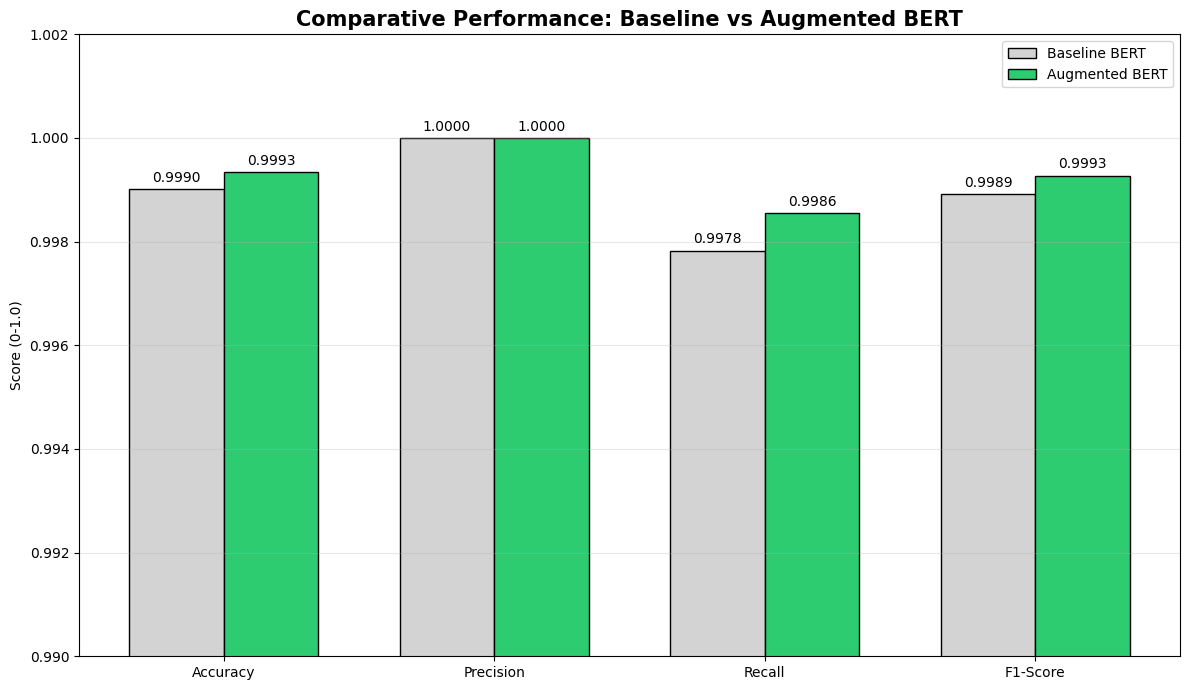

Comparison chart saved to ./outputs/


In [11]:
# Extract metric values for plotting
metrics        = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals  = [baseline_results['Accuracy'],  baseline_results['Precision'],
                  baseline_results['Recall'],     baseline_results['F1']]
augmented_vals = [augmented_results['Accuracy'],  augmented_results['Precision'],
                  augmented_results['Recall'],     augmented_results['F1']]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, baseline_vals,  width, label='Baseline BERT',  color='#d3d3d3', edgecolor='black')
rects2 = ax.bar(x + width/2, augmented_vals, width, label='Augmented BERT', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score (0-1.0)')
ax.set_title('Comparative Performance: Baseline vs Augmented BERT', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.99, 1.002)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./outputs/final_comparison_graph.png', dpi=300)
plt.show()
print("Comparison chart saved to ./outputs/")

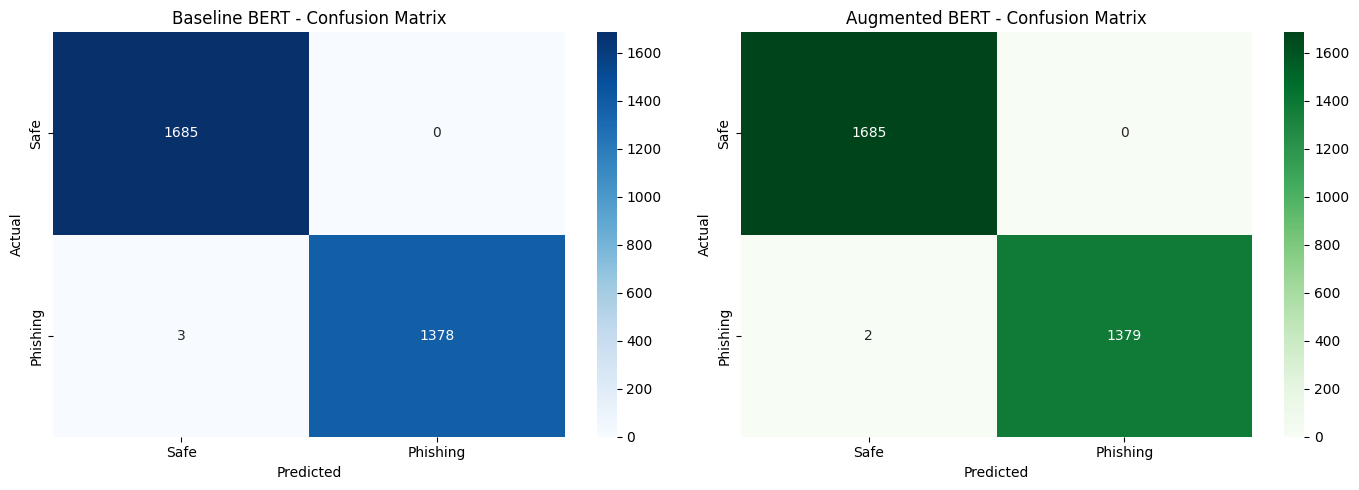

Confusion matrices saved to ./outputs/


In [12]:
# Generate predictions from both models on the same test set
# This enables direct visual comparison of classification behaviour
baseline_eval_output  = Trainer(model=baseline_model_eval).predict(test_dataset)
augmented_eval_output = Trainer(model=aug_model_eval).predict(test_dataset)


# Convert logits to predicted class labels
baseline_p  = np.argmax(baseline_eval_output.predictions,  axis=1)
augmented_p = np.argmax(augmented_eval_output.predictions, axis=1)
true_labels = baseline_eval_output.label_ids

# Build confusion matrices for both models
cm_base = confusion_matrix(true_labels, baseline_p)
cm_aug  = confusion_matrix(true_labels, augmented_p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Safe', 'Phishing'],
            yticklabels=['Safe', 'Phishing'])
ax1.set_title('Baseline BERT - Confusion Matrix')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Safe', 'Phishing'],
            yticklabels=['Safe', 'Phishing'])
ax2.set_title('Augmented BERT - Confusion Matrix')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('./outputs/final_confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved to ./outputs/")